# BÁO CÁO PROJECT I LẦN 3
Người thực hiện: Nguyễn Mạnh Thắng - 20235426  
Ngưới hướng dẫn: Phạm Minh Tuấn

## I. Giới thiệu


Báo cáo lần này sẽ sử dụng một tập dữ liệu mới trên Kaggle, [link](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset). Bộ dữ liệu này bao gồm 5574 tin nhắn SMS (English SMS) đã được gắn nhãn, mỗi mẫu dữ liệu sẽ có 2 colunms: v1(ham/spam), v2(raw text). Do các mẫu dữ liệu chưa được vectorize nên báo cáo này sẽ sử dụng TF-IDF cho việc vectorize. Ngoài sử dụng thuật toán SVM để phân loại, trong báo cáo cũng sử dụng thêm thuật toán Naive Bayes để so sánh hiệu suất phân loại giữa 2 thuật toán. 

## II. Xử lý dữ liệu

### 1. Tải các thư viện

In [1]:
import numpy as np        
import pandas as pd      
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords    
from nltk.stem.porter import PorterStemmer
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
nltk.download('stopwords')
nltk.download('punkt') 
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AD\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\AD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\AD\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### 2. Tải dataset

Tiến hành tải dataset, và in ra 5 mẫu dữ liệu đầu tiên. 

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### 3. Làm sạch dữ liệu

Đầu tiên, ta sẽ bỏ 3 colunm 2, 3, 4 không liên quan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Tiếp theo, sẽ thay đổi tên 2 colunms còn lại thành các tên khác phù hợp, và chuyển các label ở dạng text(ham/spam) về dạng 0/1(0: ham, 1: spam). 

In [8]:
df.rename(columns = {'v1': 'label', 'v2': 'text'}, inplace = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df['label'] = LabelEncoder().fit_transform(df['label'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Tiếp theo, ta sẽ kiểm tra xem trong dataset có những mẫu bị lặp lại hay không, nếu có ta sẽ tiến hành loại bỏ. 

In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df.drop_duplicates(keep = 'first')

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


Xác định tỷ lệ phần trăm các tin nhắn ham và spam. 

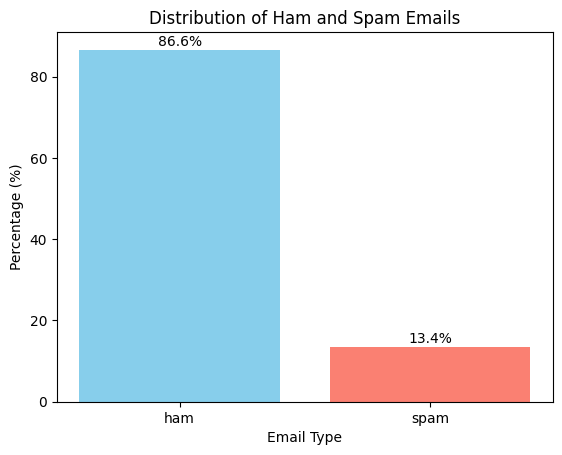

In [13]:
label_counts = df['label'].value_counts()
label_percent = (label_counts/len(df))*100
# label_percent
label_percent.index = ['ham', 'spam']
plt.bar(label_percent.index, label_percent.values, color=['skyblue', 'salmon'])
plt.xlabel("Email Type")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Ham and Spam Emails")
for i, v in enumerate(label_percent.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

### 4. Tiền xử lý dữ liệu

Ở bước này, ta sẽ loại bỏ, tinh chỉnh các yếu tố (dấu câu, chữ viết hoa, các từ được đã được chia động từ...) ở phần *text* tại mỗi mẫu dữ liệu, để đảm bảo các *features* thu được sẽ dựa trên ngữ nghĩa, tránh hiện tượng *model* học dựa trên những *features* không mang nhiều ý nghĩa phân biệt về mặt ngữ nghĩa và tránh việc *model* sử dụng các *features* tương tự nhau về mặt ngữ nghĩa để phân loại. Ví dụ: nếu như ta không tinh chỉnh chữ viết hoa thành chữ viết thường, với trường hợp 2 chữ 't' và 'T', như vậy nếu như mà trong các ham email chỉ có chữ 't' nhỏ, còn trong các spam email chỉ có chữ 'T' lớn model hoàn toàn có thể sử dụng 2 *features* này để phân loại email. Và giả sử, ta có một ham email không có chữ 't' nhỏ nào, mà lại chứ nhiều chữ 'T' lớn thì khả năng cao nó sẽ được phân loại là spam, như vậy ta thấy nếu chúng ta dùng các *features* gần như không biệt nhau về mặt ngữ nghĩa hoặc là không có nhiều ý nghĩa về mặt ngữ nghĩa thì hiệu suất trên thực tế của *model* chắc chắn sẽ không tốt. 

Cụ thể, ở đây, ta sẽ tiến hành chuẩn hoá *text* về *lowercase*; xoá các kí tự đặc biệt, *stopwords*, *punctuation*; chuẩn hoá các từ đã được chia động từ về dạng chuẩn (e.g: playing -> play). 

In [14]:
# Sử dụng để chuẩn hoá các từ đã chia động từ về dạng chuẩn; 
ps = PorterStemmer()

# Hàm tiền xử lý dữ liệu, làm các việc đã liệt kê ở trên; 
def transform_text(text):
    # Chuẩn hoá text về lowercase; 
    text = text.lower()
    
    # Lấy các word token để phục vụ cho việc lọc các ký tự đặc biệt
    # , stopwords, punctuation;
    text = nltk.word_tokenize(text)
    
    # Loại bỏ các ký tự đặc biệt; 
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    # Loại bỏ stopwords, punctuation; 
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
        
    # Chuẩn hoá các từ đã chia động từ về dạng chuẩn;
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    # Kết hợp những word token đã được xử lý vào một xâu string như ban đầu; 
    return " ".join(y)

Tiếp theo, ta sẽ tiến hành chuyển đổi (transform) *text*.

In [15]:
df['trans_text'] = df['text'].apply(transform_text)

In [16]:
df.head()

,label,text,trans_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


### 5. Áp dụng thuật toán

Đầu tiên, ta sẽ thực hiện trích chuẩn các *trans_text*, ở đây ta sẽ sử dụng TfidfVectorizer để tiến hành trích chuẩn. 

In [17]:
X = TfidfVectorizer(max_features = 3000).fit_transform(df['trans_text']).toarray()
y = df['label'].values

In [18]:
X, y

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 3000)),
 array([0, 0, 1, ..., 0, 0, 0], shape=(5572,)))

Tiếp theo, ta sẽ tách tập dữ liệu ban đầu ra thành các tập train và tập test. 

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [20]:
X_train, y_train

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(4179, 3000)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(4179,)))

In [21]:
X_test, y_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(1393, 3000)),
 array([0, 1, 0, ..., 0, 0, 0], shape=(1393,)))

#### Áp dụng thuật toán Soft margin SVM 

In [22]:
svc = SVC(kernel='linear', C=100)
svc.fit(X_train, y_train)
print("Accuracy score of Soft marign SVM for training set:", accuracy_score(y_train, svc.predict(X_train)))
print("Accuracy score of Soft marign SVM for testing set:", accuracy_score( y_test, svc.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("Precision score of Soft marign SVM for training set:", precision_score(y_train, svc.predict(X_train)))
print("Precision score of Soft marign SVM for testing set:", precision_score(y_test, svc.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("Recall score of Soft marign SVM for training set:", recall_score(y_train, svc.predict(X_train)))
print("Recall score of Soft marign SVM for testing set:", recall_score(y_test, svc.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("F1 score of Soft marign SVM for training set:", f1_score(y_train, svc.predict(X_train)))
print("F1 score of Soft marign SVM for testing set:", f1_score(y_test, svc.predict(X_test)))

Accuracy score of Soft marign SVM for training set: 0.9992821249102656
Accuracy score of Soft marign SVM for testing set: 0.9741564967695621
-----------------------------------------------------------------------------------------------------
Precision score of Soft marign SVM for training set: 0.9981785063752276
Precision score of Soft marign SVM for testing set: 0.9086294416243654
-----------------------------------------------------------------------------------------------------
Recall score of Soft marign SVM for training set: 0.9963636363636363
Recall score of Soft marign SVM for testing set: 0.9086294416243654
-----------------------------------------------------------------------------------------------------
F1 score of Soft marign SVM for training set: 0.997270245677889
F1 score of Soft marign SVM for testing set: 0.9086294416243654


#### Áp dụng thuật toán Naive Bayes

In [23]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
print("Accuracy score of NB for training set:", accuracy_score( y_train, mnb.predict(X_train)))
print("Accuracy score of NB for testing set:", accuracy_score( y_test, mnb.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("Precision score of NB for training set:", precision_score(y_train, mnb.predict(X_train)))
print("Precision score of NB for testing set:", precision_score(y_test, mnb.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("Recall score of NB for training set:", recall_score(y_train, mnb.predict(X_train)))
print("Recall score of NB for testing set:", recall_score(y_test, mnb.predict(X_test)))
print('-----------------------------------------------------------------------------------------------------')
print("F1 score of NB for training set:", f1_score(y_train, mnb.predict(X_train)))
print("F1 score of NB for testing set:", f1_score(y_test, mnb.predict(X_test)))

Accuracy score of NB for training set: 0.9803780808805934
Accuracy score of NB for testing set: 0.9755922469490309
-----------------------------------------------------------------------------------------------------
Precision score of NB for training set: 0.9957627118644068
Precision score of NB for testing set: 1.0
-----------------------------------------------------------------------------------------------------
Recall score of NB for training set: 0.8545454545454545
Recall score of NB for testing set: 0.8274111675126904
-----------------------------------------------------------------------------------------------------
F1 score of NB for training set: 0.9197651663405088
F1 score of NB for testing set: 0.9055555555555556


## III. Kết luận

Khi dự đoán một email spam hay ham, ta sẽ phải ưu tiên các mô hình có precison_score cao, bởi vì cái giá phải trả cho việc phân loại ham thành spam sẽ khá đắt. Ví dụ: nếu mô hình phân loại một email thông báo trúng tuyển thành spam thì ảnh hưởng đến cả sự nghiệp của user. Vậy nên, dựa vào kết quả ta thấy mô hình Naive Bayes sẽ làm việc tốt hơn mô hình Soft margin SVM. 